# Per-paper results table (GT vs methods)

Given a `paper_id` (Study#), this notebook:

- Finds the latest prediction CSV for each method (`direct_llm`, `static_workflow`, `mas`) for the configured model/tag.
- Loads ground truth rows from `data/wopke_paper_code/Database for combined sample 2015-03-05.csv` (replication columns aliased to `Replications SC1` / `SC2` / `IC1` / `IC2`).
- Prints a **field-by-field** table showing extracted values from each method + ground truth + presence/confusion + similarity score.


In [1]:
from __future__ import annotations

import csv
import re
import sys
from pathlib import Path

try:
    import pandas as pd  # type: ignore
except Exception:  # pragma: no cover
    pd = None


def find_repo_root(start: Path | None = None) -> Path:
    p = start or Path.cwd()
    for _ in range(6):
        if (p / "outputs").exists() and (p / "src").exists():
            return p
        p = p.parent
    return start or Path.cwd()


repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
outputs_root = repo_root / "outputs"
gt_path = repo_root / "data" / "wopke_paper_code" / "Database for combined sample 2015-03-05.csv"

# --- Configure which run outputs to load ---
provider_model_tag = "google_gemini-3-1-flash-lite-preview"
n_fields_tag = "42fields"

METHODS: dict[str, str] = {
    "direct_llm": "direct_llm",
    "workflow": "static_workflow",
    "MAS": "mas",
}

print("repo_root:", repo_root)
print("outputs_root:", outputs_root)
print("gt_path:", gt_path)
print("provider_model_tag:", provider_model_tag)
print("n_fields_tag:", n_fields_tag)
print("methods:", METHODS)


repo_root: /home/com3dian/Github/meta_analysis_agents
outputs_root: /home/com3dian/Github/meta_analysis_agents/outputs
gt_xlsx_path: /home/com3dian/Github/meta_analysis_agents/data/wopke_100/annotation/wopke100.xlsx
provider_model_tag: google_gemini-3-1-flash-lite-preview
n_fields_tag: 42fields
methods: {'direct_llm': 'direct_llm', 'workflow': 'static_workflow', 'MAS': 'mas'}


In [2]:
def is_present(v) -> bool:
    if v is None:
        return False
    s = str(v).strip()
    if not s:
        return False
    s_low = s.lower()
    return s_low not in {"nan", "none", "null", "n/a", "na"}


def read_prediction_csv(csv_path: str) -> tuple[list[dict], list[str]]:
    with open(csv_path, "r", encoding="utf-8", errors="ignore", newline="") as f:
        reader = csv.DictReader(f)
        fieldnames = list(reader.fieldnames or [])
        rows = [dict(r) for r in reader]
    return rows, fieldnames


def scan_latest_for_method(method_prefix: str) -> dict[int, str]:
    """Return {paper_id: csv_path} for latest run per paper_id."""
    if not outputs_root.exists():
        raise FileNotFoundError(f"outputs folder not found: {outputs_root}")

    needle = f"{method_prefix}_{provider_model_tag}_{n_fields_tag}_"
    paper_id_re = re.compile(r"^(?P<paper_id>\d+)_")
    date_re = re.compile(r"_(?P<date>\d{4}-\d{2}-\d{2})\.csv$")

    latest_by_pid: dict[int, dict] = {}
    for dated_dir in sorted(outputs_root.iterdir()):
        if not dated_dir.is_dir():
            continue
        if not re.match(r"^\d{4}-\d{2}-\d{2}$", dated_dir.name):
            continue

        for csv_path in dated_dir.glob("*.csv"):
            name = csv_path.name
            if needle not in name:
                continue

            m_pid = paper_id_re.match(name)
            m_date = date_re.search(name)
            if not m_pid or not m_date:
                continue

            pid = int(m_pid.group("paper_id"))
            date = m_date.group("date")

            prev = latest_by_pid.get(pid)
            if prev is None or date > prev["date"]:
                latest_by_pid[pid] = {"date": date, "csv_path": str(csv_path)}

    return {pid: v["csv_path"] for pid, v in latest_by_pid.items()}


def load_ground_truth_by_study_id() -> dict[int, list[dict]]:
    """Load combined-sample GT grouped by Study#, with standard field aliases."""
    from src.experimentutils.eval_utils import load_ground_truth_by_study_id as _load_gt
    if not gt_path.exists():
        raise FileNotFoundError(f"Ground truth CSV not found: {gt_path}")
    return _load_gt(str(gt_path))


# --- Load data ---
pred_by_method: dict[str, dict[int, str]] = {}
for method_label, method_prefix in METHODS.items():
    pred_by_method[method_label] = scan_latest_for_method(method_prefix)
    print(method_label, "papers:", len(pred_by_method[method_label]))

from src.experimentutils.eval_utils import wopke_100_shared_fields

gt_by_id = load_ground_truth_by_study_id()
print("GT papers:", len(gt_by_id))

some_pid = next(iter(gt_by_id.keys()))
some_gt_rows = gt_by_id.get(some_pid, [])
gt_keys = set(some_gt_rows[0].keys()) if some_gt_rows else set()
shared_fields = wopke_100_shared_fields(gt_keys)

print("shared_fields (standard ∩ GT):", len(shared_fields))
print("example shared_fields:", shared_fields[:10])
print("has Replications SC1:", "Replications SC1" in shared_fields)
print("has N Unit:", "N Unit" in shared_fields)


direct_llm papers: 10
workflow papers: 10
MAS papers: 10
GT papers: 100
canonical_pred_fields: 42
shared_fields (intersection with GT header): 39
example shared_fields: ['Year of data', 'Duration of experiment', 'Experimental design', 'Sowing date 1', 'Sowing date 2', 'Harvest date 1', 'Harvest date 2', 'Lat', 'Lon', 'Crop species 1']


In [3]:
# --- Unit-aware evaluation (shared util) ---

from src.experimentutils.eval_utils import (
    evaluate_record_pair_with_units,
    infer_gt_spreadsheet_columns,
    match_records_greedy_with_units,
    overall_metrics_with_units,
    pred_row_after_swap,
)


def _gt_spreadsheet_for_fields(fields: list[str]) -> bool:
    return infer_gt_spreadsheet_columns(fields)


def overall_metrics(pred_rows: list[dict], gt_rows: list[dict], fields: list[str]) -> dict:
    return overall_metrics_with_units(
        pred_rows, gt_rows, fields, gt_spreadsheet=_gt_spreadsheet_for_fields(fields)
    )


def _best_field_similarity(gt_rows: list[dict], pred_rows: list[dict], field: str, fields: list[str]) -> float:
    gt_ss = _gt_spreadsheet_for_fields(fields)
    best = 0.0
    found = False
    for gt_row in gt_rows:
        if not is_present(gt_row.get(field)):
            continue
        for pred_row in pred_rows:
            ev = evaluate_record_pair_with_units(
                pred_row, gt_row, fields, gt_spreadsheet=gt_ss
            )
            s = ev.field_scores.get(field, 0.0)
            if is_present(pred_row.get(field)) or field in ev.field_scores:
                best = max(best, s)
                found = True
    return best if found else float("nan")


# --- Per-paper table helpers ---

def _pretty_values(rows: list[dict], field: str, *, max_items: int = 6) -> str:
    vals: list[str] = []
    seen = set()
    for r in rows:
        v = r.get(field)
        if not is_present(v):
            continue
        s = str(v).strip()
        if s not in seen:
            seen.add(s)
            vals.append(s)
    if not vals:
        return ""
    if len(vals) <= max_items:
        return "; ".join(vals)
    return "; ".join(vals[:max_items]) + f" …(+{len(vals)-max_items})"


def _presence_label(gt_rows: list[dict], pred_rows: list[dict], field: str) -> str:
    gt_p = any(is_present(r.get(field)) for r in gt_rows)
    pr_p = any(is_present(r.get(field)) for r in pred_rows)
    if gt_p and pr_p:
        return "TP"
    if gt_p and (not pr_p):
        return "FN"
    if (not gt_p) and pr_p:
        return "FP"
    return "TN"


def paper_label(pid: int) -> str:
    rows = gt_by_id.get(pid, [])
    if not rows:
        return str(pid)
    rec = rows[0]

    author = rec.get("Author")
    title = rec.get("Title")
    a = author.strip() if isinstance(author, str) else ""
    t = title.strip() if isinstance(title, str) else ""
    if a and t:
        return f"{a} — {t}"
    return a or t or str(pid)


def show_paper(paper_id: int, *, fields: list[str] | None = None):
    gt_rows = gt_by_id.get(paper_id, [])
    if not gt_rows:
        raise KeyError(f"paper_id={paper_id} not found in GT")

    pred_rows_by_method: dict[str, list[dict]] = {}
    for method_label in METHODS.keys():
        csv_path = pred_by_method[method_label].get(paper_id)
        if csv_path is None:
            pred_rows_by_method[method_label] = []
        else:
            pred_rows_by_method[method_label], _ = read_prediction_csv(csv_path)

    use_fields = fields or shared_fields

    print(f"paper_id={paper_id} | {paper_label(paper_id)}")
    print("Overall scores (unit-aware):")
    overall_rows = []
    for m in ["direct_llm", "workflow", "MAS"]:
        met = overall_metrics(pred_rows_by_method[m], gt_rows, use_fields)
        overall_rows.append({"method": m, **met})
        tp = met.get("tp_avg_similarity", float("nan"))
        tp_txt = f"{tp:.3f}" if tp == tp else "nan"
        print(f"  {m}: tp_avg_similarity={tp_txt}")
    print()

    if pd is not None:
        overall_df = pd.DataFrame(overall_rows)
        display(overall_df)
    else:
        overall_df = None
        for r in overall_rows:
            print(r)

    # --- Field-by-field table ---
    table_rows = []
    for f in use_fields:
        r = {
            "field": f,
            "gt": _pretty_values(gt_rows, f),
            "direct_llm": _pretty_values(pred_rows_by_method["direct_llm"], f),
            "workflow": _pretty_values(pred_rows_by_method["workflow"], f),
            "MAS": _pretty_values(pred_rows_by_method["MAS"], f),
            "presence_direct_llm": _presence_label(gt_rows, pred_rows_by_method["direct_llm"], f),
            "presence_workflow": _presence_label(gt_rows, pred_rows_by_method["workflow"], f),
            "presence_MAS": _presence_label(gt_rows, pred_rows_by_method["MAS"], f),
            "best_sim_direct_llm": _best_field_similarity(gt_rows, pred_rows_by_method["direct_llm"], f, use_fields),
            "best_sim_workflow": _best_field_similarity(gt_rows, pred_rows_by_method["workflow"], f, use_fields),
            "best_sim_MAS": _best_field_similarity(gt_rows, pred_rows_by_method["MAS"], f, use_fields),
        }
        table_rows.append(r)

    if pd is None:
        return {"overall": overall_rows, "by_field": table_rows}

    df = pd.DataFrame(table_rows)
    cols = [
        "field",
        "gt",
        "direct_llm",
        "workflow",
        "MAS",
        "presence_direct_llm",
        "presence_workflow",
        "presence_MAS",
        "best_sim_direct_llm",
        "best_sim_workflow",
        "best_sim_MAS",
    ]
    df = df[cols]

    # Explicitly display, so you see both tables even if you assign the return value.
    display(df)

    return {"overall": overall_df, "by_field": df}


def show_paper_record_pairs(
    paper_id: int,
    *,
    fields: list[str] | None = None,
    methods: list[str] | None = None,
    show_unmatched_predictions: bool = False,
    verbose: bool = False,
):
    """Display per-GT-record tables with unit-aware scores and per-pair crop swap."""

    gt_rows = gt_by_id.get(paper_id, [])
    if not gt_rows:
        raise KeyError(f"paper_id={paper_id} not found in GT")

    use_fields = fields or shared_fields
    use_methods = methods or ["direct_llm", "workflow", "MAS"]
    gt_ss = _gt_spreadsheet_for_fields(use_fields)

    pred_rows_by_method: dict[str, list[dict]] = {}
    for method_label in use_methods:
        csv_path = pred_by_method.get(method_label, {}).get(paper_id)
        if csv_path is None:
            pred_rows_by_method[method_label] = []
        else:
            pred_rows_by_method[method_label], _ = read_prediction_csv(csv_path)

    print(f"paper_id={paper_id} | {paper_label(paper_id)}")
    print(f"GT rows: {len(gt_rows)} | fields scored: {len(use_fields)}")
    print("Overall scores (unit-aware TP similarity, greedy row match + per-pair crop swap):")

    def _fmt(v: float) -> str:
        return f"{v:.3f}" if v == v else "nan"

    method_info = {}
    for m in use_methods:
        pred_rows = pred_rows_by_method.get(m, [])
        met = overall_metrics(pred_rows, gt_rows, use_fields)
        matches = match_records_greedy_with_units(
            pred_rows, gt_rows, use_fields, gt_spreadsheet=gt_ss
        )
        gt_to_match = {
            gt_i: (pred_i, ev)
            for pred_i, gt_i, ev in matches
        }
        used_pred = {pred_i for pred_i, _, _ in matches}
        method_info[m] = {
            "label": m,
            "pred_rows": pred_rows,
            "matches": matches,
            "gt_to_match": gt_to_match,
            "used_pred": used_pred,
            "metrics": met,
            "score": met.get("tp_avg_similarity", float("nan")),
        }
        print(
            f"  {m}: tp_avg_similarity={_fmt(met.get('tp_avg_similarity', float('nan')))}, "
            f"precision={_fmt(met.get('precision', float('nan')))}, "
            f"recall={_fmt(met.get('recall', float('nan')))}, "
            f"matched_rows={len(matches)}/{len(gt_rows)}"
        )

    def _score_for_sort(method_label: str) -> float:
        score = method_info[method_label]["score"]
        return score if score == score else -1.0

    ordered_methods = sorted(use_methods, key=_score_for_sort, reverse=True)
    print()

    per_gt_tables = []

    for gt_i, gt_row in enumerate(gt_rows):
        print("\n" + "=" * 88)
        print(f"GT row {gt_i}")
        for m in ordered_methods:
            info = method_info[m]
            match = info["gt_to_match"].get(gt_i)
            if match is None:
                print(f"  {m}: unmatched")
            else:
                pred_i, ev = match
                swap_txt = "SWAPPED" if ev.swapped else "not swapped"
                print(
                    f"  {m}: matched pred row {pred_i}, mean={ev.mean_score:.3f}, "
                    f"crop labels {swap_txt}"
                )

        table_rows = []
        for f in use_fields:
            row_out = {
                "field": f,
                "gt": "" if gt_row.get(f) is None else str(gt_row.get(f)),
            }

            for m in ordered_methods:
                info = method_info[m]
                label = info["label"]
                match = info["gt_to_match"].get(gt_i)

                if match is None:
                    pred_v = None
                    presence = "FN" if is_present(gt_row.get(f)) else "TN"
                    sim = float("nan")
                else:
                    pred_i, ev = match
                    pred_row = pred_row_after_swap(info["pred_rows"][pred_i], ev)
                    pred_v = pred_row.get(f)

                    gt_p = is_present(gt_row.get(f))
                    pr_p = is_present(pred_v)
                    if gt_p and pr_p:
                        presence = "TP"
                        sim = ev.field_scores.get(f, 0.0)
                    elif gt_p and (not pr_p):
                        presence = "FN"
                        sim = float("nan")
                    elif (not gt_p) and pr_p:
                        presence = "FP"
                        sim = float("nan")
                    else:
                        presence = "TN"
                        sim = float("nan")

                row_out[label] = "" if pred_v is None else str(pred_v)
                row_out[f"presence_{label}"] = presence
                row_out[f"sim_{label}"] = sim

            table_rows.append(row_out)

        if pd is not None:
            df_pair = pd.DataFrame(table_rows)
            cols = ["field", "gt"]
            for m in ordered_methods:
                label = method_info[m]["label"]
                cols.extend([label, f"presence_{label}", f"sim_{label}"])
            display(df_pair[cols])
            per_gt_tables.append(df_pair[cols])
        else:
            per_gt_tables.append(table_rows)
            for r in table_rows[:10]:
                print(r)

    extra_pred_tables = {}
    if show_unmatched_predictions:
        for m in ordered_methods:
            info = method_info[m]
            label = info["label"]
            pred_rows = info["pred_rows"]
            used_pred = info["used_pred"]
            method_tables = []
            for pred_i, pred_row in enumerate(pred_rows):
                if pred_i in used_pred:
                    continue
                if verbose:
                    print("\n" + f"Extra pred row in {label}: {pred_i} (unmatched)" + "\n")
                table_rows = []
                for f in use_fields:
                    pr_v = pred_row.get(f)
                    pr_p = is_present(pr_v)
                    table_rows.append(
                        {
                            "field": f,
                            "gt": "",
                            label: "" if pr_v is None else str(pr_v),
                            f"presence_{label}": "FP" if pr_p else "TN",
                            f"sim_{label}": float("nan"),
                        }
                    )
                if pd is not None:
                    df_pair = pd.DataFrame(table_rows)
                    display(df_pair)
                    method_tables.append(df_pair)
                else:
                    method_tables.append(table_rows)
            extra_pred_tables[label] = method_tables

    return {
        "per_gt": per_gt_tables,
        "by_method": method_info,
        "ordered_methods": ordered_methods,
        "extra_pred": extra_pred_tables,
    }


def print_prediction_rows_for_paper(
    paper_id: int,
    *,
    methods: list[str] | None = None,
):
    """Print prediction CSV paths and all predicted rows for each method."""

    use_methods = methods or ["direct_llm", "workflow", "MAS"]

    print(f"paper_id={paper_id} | {paper_label(paper_id)}")
    outputs = {}

    for m in use_methods:
        csv_path = pred_by_method.get(m, {}).get(paper_id)
        print("\n" + "=" * 88)
        print(f"method={m}")
        print("csv:", csv_path)

        if csv_path is None:
            print("[missing csv for this paper_id]")
            outputs[m] = {"csv": None, "rows": []}
            continue

        pred_rows, _ = read_prediction_csv(csv_path)
        print("n_rows:", len(pred_rows))
        for i, row in enumerate(pred_rows):
            print(f"row[{i}] = {row}")

        outputs[m] = {"csv": csv_path, "rows": pred_rows}

    return outputs


In [4]:
# Example usage
# Pick one of the paper_ids that exist in the discovered predictions
paper_ids = sorted(set().union(*(set(pred_by_method[m].keys()) for m in METHODS.keys())))
print("available paper_ids (from predictions):", paper_ids)

pid = paper_ids[3] if paper_ids else 1

# 1) Print prediction CSV files + all predicted rows for all 3 methods
# pred_dump = print_prediction_rows_for_paper(pid)

# 2) Optional: show GT↔pred per-record pair tables (greedy matched)
out = show_paper_record_pairs(pid)


available paper_ids (from predictions): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
paper_id=4 | Li, L; Sun, JH; Zhang, FS; Li, XL; Yang, SC; Rengel, Z — Wheat/maize or wheat/soybean strip intercropping I. Yield advantage and interspecific interactions on nutrients
GT rows: 4 | fields scored: 39
Overall scores (unit-aware TP similarity, greedy row match + per-pair crop swap):
  direct_llm: tp_avg_similarity=0.732, precision=0.667, recall=1.000, matched_rows=4/4
  workflow: tp_avg_similarity=0.730, precision=0.667, recall=1.000, matched_rows=4/4
  MAS: tp_avg_similarity=0.745, precision=0.667, recall=1.000, matched_rows=4/4


GT row 0
  MAS: matched pred row 0, mean=0.664, crop labels not swapped
  direct_llm: matched pred row 0, mean=0.667, crop labels not swapped
  workflow: matched pred row 0, mean=0.664, crop labels not swapped


,field,gt,MAS,presence_MAS,sim_MAS,direct_llm,presence_direct_llm,sim_direct_llm,workflow,presence_workflow,sim_workflow
0,Year of data,1997-1998,1997–1998,TP,1.000000,1997–1998,TP,1.000000,1997–1998,TP,1.000000
1,Duration of experiment,2,1 growing season,TP,0.000000,1 growing season,TP,0.000000,1 growing season,TP,0.000000
2,Experimental design,Split-plot,2x2x3 split-split-plot,TP,0.645161,split-split-plot,TP,0.769231,2x2x3 split-split-plot,TP,0.645161
3,Sowing date 1,35509,20 March,TP,1.000000,20 March,TP,1.000000,Wheat sown 20 March,TP,1.000000
4,Sowing date 2,35536,16 April,TP,1.000000,16 April,TP,1.000000,Maize sown 16 April,TP,1.000000
5,Harvest date 1,35626,15 July,TP,1.000000,15 July,TP,1.000000,Wheat harvested 15 July,TP,1.000000
6,Harvest date 2,35697,24 September,TP,1.000000,24 September,TP,1.000000,Maize harvested 24 September,TP,1.000000
7,Lat,38.61,38.62,TP,0.000000,38.37,TP,0.000000,38.37,TP,0.000000
8,Lon,102.66,102.67,TP,0.000000,102.40,TP,0.000000,102.40,TP,0.000000
9,Crop species 1,Wheat,Wheat,TP,1.000000,Wheat,TP,1.000000,Wheat,TP,1.000000



GT row 1
  MAS: matched pred row 2, mean=0.664, crop labels not swapped
  direct_llm: matched pred row 2, mean=0.667, crop labels not swapped
  workflow: matched pred row 2, mean=0.664, crop labels not swapped


,field,gt,MAS,presence_MAS,sim_MAS,direct_llm,presence_direct_llm,sim_direct_llm,workflow,presence_workflow,sim_workflow
0,Year of data,1997-1998,1997–1998,TP,1.000000,1997–1998,TP,1.000000,1997–1998,TP,1.000000
1,Duration of experiment,2,1 growing season,TP,0.000000,1 growing season,TP,0.000000,1 growing season,TP,0.000000
2,Experimental design,Split-plot,2x2x3 split-split-plot,TP,0.645161,split-split-plot,TP,0.769231,2x2x3 split-split-plot,TP,0.645161
3,Sowing date 1,35509,20 March,TP,1.000000,20 March,TP,1.000000,Wheat sown 20 March,TP,1.000000
4,Sowing date 2,35536,16 April,TP,1.000000,16 April,TP,1.000000,Maize sown 16 April,TP,1.000000
5,Harvest date 1,35626,15 July,TP,1.000000,15 July,TP,1.000000,Wheat harvested 15 July,TP,1.000000
6,Harvest date 2,35697,24 September,TP,1.000000,24 September,TP,1.000000,Maize harvested 24 September,TP,1.000000
7,Lat,38.61,38.62,TP,0.000000,38.37,TP,0.000000,38.37,TP,0.000000
8,Lon,102.66,102.67,TP,0.000000,102.40,TP,0.000000,102.40,TP,0.000000
9,Crop species 1,Wheat,Wheat,TP,1.000000,Wheat,TP,1.000000,Wheat,TP,1.000000



GT row 2
  MAS: matched pred row 4, mean=0.699, crop labels not swapped
  direct_llm: matched pred row 4, mean=0.673, crop labels not swapped
  workflow: matched pred row 4, mean=0.673, crop labels not swapped


,field,gt,MAS,presence_MAS,sim_MAS,direct_llm,presence_direct_llm,sim_direct_llm,workflow,presence_workflow,sim_workflow
0,Year of data,1997-1998,1997–1998,TP,1.00,1997–1998,TP,1.00,1997–1998,TP,1.00
1,Duration of experiment,2,1 growing season,TP,0.00,1 growing season,TP,0.00,1 growing season,TP,0.00
2,Experimental design,Split-plot,split-plot,TP,1.00,split-plot,TP,1.00,Split-plot,TP,1.00
3,Sowing date 1,35514,25 March,TP,1.00,25 March,TP,1.00,Wheat sown 25 March,TP,1.00
4,Sowing date 2,35534,14 April,TP,1.00,14 April,TP,1.00,Soybean sown 14 April,TP,1.00
5,Harvest date 1,35636,25 July,TP,1.00,25 July,TP,1.00,Wheat harvested 25 July,TP,1.00
6,Harvest date 2,35695,22 September,TP,1.00,22 September,TP,1.00,Soybean harvested 22 September,TP,1.00
7,Lat,37.08,37.08,TP,1.00,37.05,TP,0.00,37.05,TP,0.00
8,Lon,104.66,104.67,TP,0.00,104.40,TP,0.00,104.40,TP,0.00
9,Crop species 1,Wheat,Wheat,TP,1.00,Wheat,TP,1.00,Wheat,TP,1.00



GT row 3
  MAS: matched pred row 5, mean=0.571, crop labels not swapped
  direct_llm: matched pred row 5, mean=0.545, crop labels not swapped
  workflow: matched pred row 5, mean=0.545, crop labels not swapped


,field,gt,MAS,presence_MAS,sim_MAS,direct_llm,presence_direct_llm,sim_direct_llm,workflow,presence_workflow,sim_workflow
0,Year of data,1997-1998,1997–1998,TP,1.00,1997–1998,TP,1.00,1997–1998,TP,1.00
1,Duration of experiment,2,1 growing season,TP,0.00,1 growing season,TP,0.00,1 growing season,TP,0.00
2,Experimental design,Split-plot,split-plot,TP,1.00,split-plot,TP,1.00,Split-plot,TP,1.00
3,Sowing date 1,35514,25 March,TP,1.00,25 March,TP,1.00,Wheat sown 25 March,TP,1.00
4,Sowing date 2,35534,14 April,TP,1.00,14 April,TP,1.00,Soybean sown 14 April,TP,1.00
5,Harvest date 1,35636,25 July,TP,1.00,25 July,TP,1.00,Wheat harvested 25 July,TP,1.00
6,Harvest date 2,35695,22 September,TP,1.00,22 September,TP,1.00,Soybean harvested 22 September,TP,1.00
7,Lat,37.08,37.08,TP,1.00,37.05,TP,0.00,37.05,TP,0.00
8,Lon,104.66,104.67,TP,0.00,104.40,TP,0.00,104.40,TP,0.00
9,Crop species 1,Wheat,Wheat,TP,1.00,Wheat,TP,1.00,Wheat,TP,1.00


## Per-field average score bar plot (single paper)

Grouped bars: for each field, average unit-aware similarity score across greedy-matched GT↔pred record pairs.

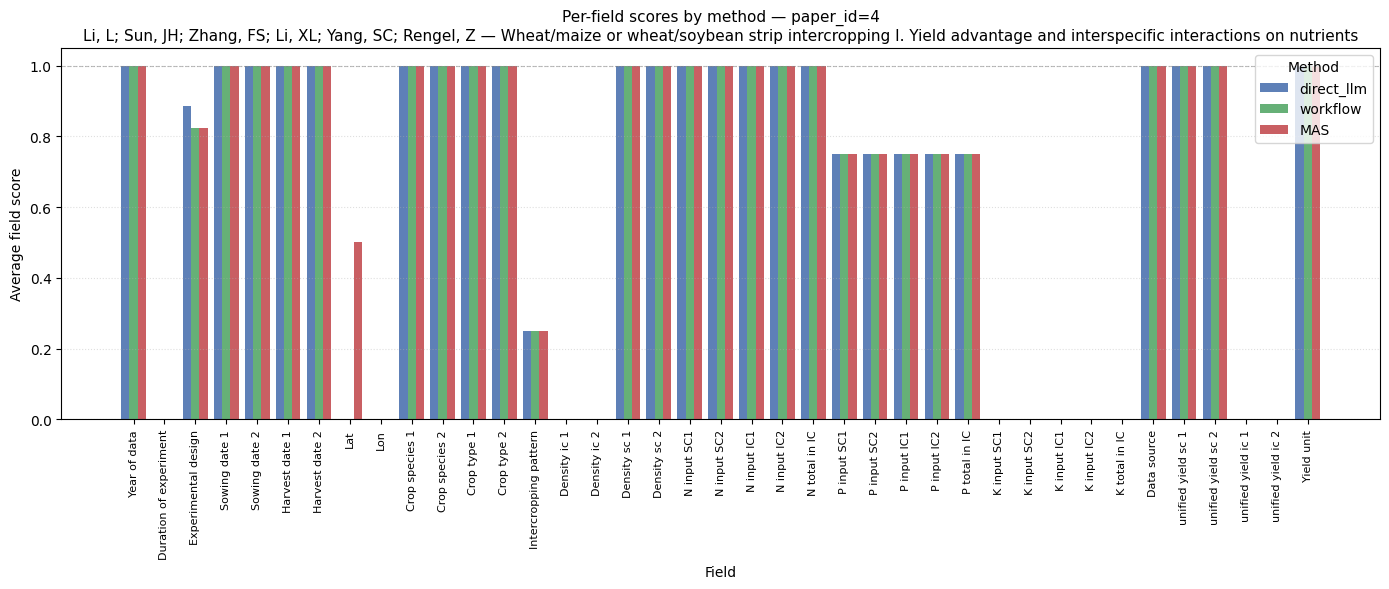

,field,direct_llm,workflow,MAS
0,Year of data,1.000000,1.000000,1.000000
1,Duration of experiment,0.000000,0.000000,0.000000
2,Experimental design,0.884615,0.822581,0.822581
3,Sowing date 1,1.000000,1.000000,1.000000
4,Sowing date 2,1.000000,1.000000,1.000000
5,Harvest date 1,1.000000,1.000000,1.000000
6,Harvest date 2,1.000000,1.000000,1.000000
7,Lat,0.000000,0.000000,0.500000
8,Lon,0.000000,0.000000,0.000000
9,Crop species 1,1.000000,1.000000,1.000000


In [5]:
import matplotlib.pyplot as plt
import numpy as np

from src.experimentutils.eval_utils import match_records_greedy_with_units


def per_field_avg_scores_for_paper(
    paper_id: int,
    *,
    fields: list[str] | None = None,
    methods: list[str] | None = None,
) -> "pd.DataFrame":
    """Average field score per method (unit-aware), averaged over matched GT rows."""
    gt_rows = gt_by_id.get(paper_id, [])
    if not gt_rows:
        raise KeyError(f"paper_id={paper_id} not found in GT")

    use_fields = fields or shared_fields
    use_methods = methods or ["direct_llm", "workflow", "MAS"]
    gt_ss = _gt_spreadsheet_for_fields(use_fields)

    rows: list[dict] = []
    for f in use_fields:
        row: dict = {"field": f}
        for m in use_methods:
            csv_path = pred_by_method.get(m, {}).get(paper_id)
            if csv_path is None:
                row[m] = float("nan")
                continue
            pred_rows, _ = read_prediction_csv(csv_path)
            matches = match_records_greedy_with_units(
                pred_rows, gt_rows, use_fields, gt_spreadsheet=gt_ss
            )
            scores = [ev.field_scores.get(f, 0.0) for _, _, ev in matches]
            row[m] = float(np.mean(scores)) if scores else float("nan")
        rows.append(row)

    return pd.DataFrame(rows)


def plot_per_field_scores_barplot(
    paper_id: int,
    *,
    fields: list[str] | None = None,
    methods: list[str] | None = None,
    figsize: tuple[float, float] | None = None,
):
    use_methods = methods or ["direct_llm", "workflow", "MAS"]
    df = per_field_avg_scores_for_paper(paper_id, fields=fields, methods=use_methods)

    n_fields = len(df)
    if figsize is None:
        figsize = (max(14, n_fields * 0.35), 6)

    x = np.arange(n_fields)
    width = 0.8 / len(use_methods)
    colors = {"direct_llm": "#4C72B0", "workflow": "#55A868", "MAS": "#C44E52"}

    fig, ax = plt.subplots(figsize=figsize)
    for i, m in enumerate(use_methods):
        offset = (i - (len(use_methods) - 1) / 2) * width
        ax.bar(
            x + offset,
            df[m].values,
            width=width,
            label=m,
            color=colors.get(m, None),
            alpha=0.9,
        )

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Average field score")
    ax.set_xlabel("Field")
    ax.set_title(
        f"Per-field scores by method — paper_id={paper_id}\n{paper_label(paper_id)}",
        fontsize=11,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(df["field"], rotation=90, ha="center", fontsize=8)
    ax.legend(title="Method", loc="upper right")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return df


# Same paper as the table above (`pid` from previous cell)
plot_df = plot_per_field_scores_barplot(pid)
plot_df

In [6]:
paper_ids

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

quick and dirty -> ROUGE (do not make it long and dirty)
long and accuruay -> (creating the rule, and use the if statement)

it is difficult to assess this 

Evaluation
We assess extraction quality at the cell level by comparing each predicted field with its corresponding ground-truth field, after greedily matching rows within each paper. Each cell pair is categorized into one of four outcomes: True Positive (TP), where both prediction and ground truth contain a value; False Negative (FN), where a ground-truth value is missed by the prediction; False Positive (FP), where a value is predicted despite no ground-truth value (i.e., hallucination); and True Negative (TN), where both are empty. Based on these definitions, we report three complementary metrics. First, Accuracy in True Positive pairs evaluates the correctness of extracted values when both prediction and ground truth are present by computing a normalized, type-aware similarity score in [0,1]  (e.g., accounting for numeric or year formats), averaged across all TP cells. Second, the Factual rate (TP/(TP+FP)) measures precision by quantifying the proportion of predicted values that correspond to actual ground-truth entries, thus reflecting resistance to hallucination. Third, the Retrieval rate (TP/(TP+FN)) captures recall by indicating how many ground-truth values are successfully retrieved by the method. Together, these metrics provide a balanced evaluation of correctness, faithfulness, and coverage. 

—--------------------------
Dates → figure out how to validate. 
Name: “TP Accuracy” instead of similarity 
No specificity
When answer gives multiple options, including 1 correct, the score should be the fraction that is correct. 
Semantic differences are not scored properly (Mg/ha vs. Mg ha-1). → update prompt. 
Experimental design → limited set of options, hard-code some rules. For each option, list different ways of writing it and take max score of each. 
Lon/lat: leave out extra decimals (beyond ground-truth).  Update prompt to prevent rounding down. 
Crop species 1/2: create a copy and swap the 1 and 2 labels. Report max score across both.
Yield unit: have function that takes GT and replaces ‘/’ with space and add ‘-1’ at the end. report max score of both. Also swap Mg vs t; both are equivalent. 
Species name: double-check that GT is always common name, and if so, update prompt .

paper_id=10; row 0 has 1.0 score for best_workflow which should be < 1
same issue paper_id=0 for N input. All scores only have 1-decimal float .



To ask Wopke:
paper_id=0: unit is different (between original paper and Wopke’s dataset), and therefore also yield values. Why?

Idea:
Use rules for validation, hard-code specific rules for these columns. 
At the very end, use LLM as a judge to compare accuracy. If accurate: LLM as a judge can be default, and rule-based verifies it. If inaccurate, nice extra result (and rule-based stays). 


